In [1]:
from model_ranking import (
    load_h5,
    adaRandError_eval,
    get_random_colors,
    get_roi_slice,
    calculate_instance_rand_indices,
    get_mask,
    assign_unique_ids_to_value,
)
import matplotlib.pyplot as plt
import numpy as np

INFO: P [MainThread] 2025-10-13 13:05:28,227 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ov_gt_path = "/scratch/talks/data/Ovules/GT2x/test/N_294_final_crop_ds2.h5"
ov_gt = load_h5(ov_gt_path, "label_with_ignore")
ov_raw = load_h5(ov_gt_path, "raw")

In [3]:
ov_perturbed_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/gauss_a01-015/predictions/N_294_final_crop_ds2_predictions.h5"
ov_unperturbed_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/FlyWing_to_Ovules_gap/consistency/P2/fw_model_Unet2/norm_50_950/none/predictions/N_294_final_crop_ds2_predictions.h5"
ov_seg_p = load_h5(ov_perturbed_path, "segmentation")
ov_seg_up = load_h5(ov_unperturbed_path, "segmentation")
ov_patch_indexes = load_h5(ov_perturbed_path, 'patch_index')

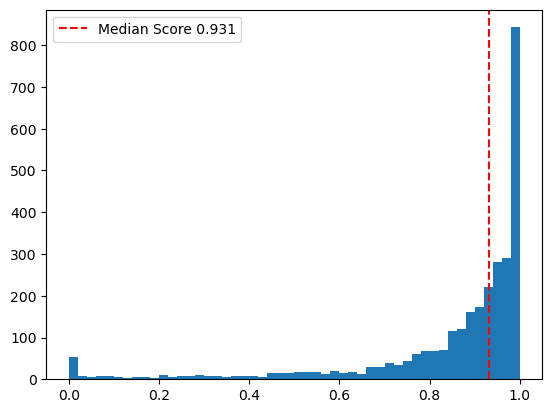

In [4]:
ov_consis_scores = load_h5(ov_perturbed_path, "AdaRandError_consis")
median_score = 1 - np.nanmedian(ov_consis_scores[:, 0])
plt.hist(1 - ov_consis_scores[:, 0], bins=50)
plt.axvline(x=median_score, color='r', linestyle='--', label=f'Median Score {median_score:.3f}')
plt.legend()
plt.show()

In [5]:
ids_low_consis = np.where(((1 - ov_consis_scores[:, 0]) > 0.6) & (1 - ov_consis_scores[:, 0] < 0.8))[0]
print(len(ids_low_consis))

355


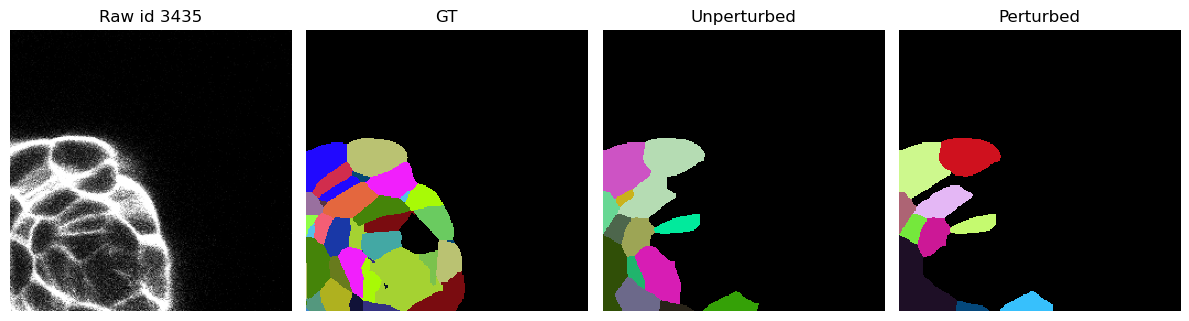

In [6]:
id = ids_low_consis[180]
_, axs = plt.subplots(1, 4, figsize=(12, 4))
patch_roi = get_roi_slice(ov_patch_indexes[id])
axs[0].imshow(ov_raw[patch_roi].squeeze(), cmap="gray")
axs[0].set_title("Raw id {}".format(id))
axs[1].imshow(ov_gt[patch_roi].squeeze(), cmap=get_random_colors(ov_gt[patch_roi]), interpolation='nearest')
axs[1].set_title("GT")
axs[2].imshow(ov_seg_up[id].squeeze(), cmap=get_random_colors(ov_seg_up[id]), interpolation='nearest')
axs[2].set_title("Unperturbed")
axs[3].imshow(ov_seg_p[id].squeeze(), cmap=get_random_colors(ov_seg_p[id]), interpolation='nearest')
axs[3].set_title("Perturbed")
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
from skimage.metrics import adapted_rand_error
from model_ranking import assign_unique_ids_to_value

id = 3435
up_seg = ov_seg_up[id].squeeze()
p_seg = ov_seg_p[id].squeeze()
mask = up_seg == 11
up_seg = up_seg * mask
p_seg = np.zeros_like(up_seg)
p_seg = assign_unique_ids_to_value(p_seg, [0])

are, prec, rec = adapted_rand_error(up_seg, p_seg)
print(1 - are)
# plt.imshow(up_seg, cmap=get_random_colors(up_seg), interpolation='nearest')
# plt.title("Unperturbed")
# plt.axis('off')
# plt.show()

0.0


invalid value encountered in scalar divide


In [11]:
# unperturbed patch
unique = np.unique(ov_seg_up[id])
unique = unique[unique != 0]
print(unique)
mask = get_mask(ov_seg_up[id], ov_seg_p[id], threshold=0)
masked_p_seg = ov_seg_p[id][mask]
masked_up_seg = ov_seg_up[id][mask]
masked_p_seg = assign_unique_ids_to_value(masked_p_seg, [0])

RI_score = calculate_instance_rand_indices(masked_up_seg, masked_p_seg, unique)
print(f"Corrected Rand Index score {RI_score}")


[ 1  2  3  4  5  6  7  8  9 10 11 12 13]
Corrected Rand Index score {1: 0.9134461800531898, 2: 0.9957744795867924, 3: 0.9895676129951195, 4: 0.9956626127826725, 5: 0.9987317713538365, 6: 0.9993447841102475, 7: 0.998580967750997, 8: 0.9185695566149318, 9: 0.9302735811408231, 10: 0.9864238968841479, 11: 0.8892723713053043, 12: 0.9985133508824866, 13: 0.993271212542263}
